In [1]:
from typing import Literal, Any, Callable, Iterable
from pandas import DataFrame, read_csv, concat, get_dummies, concat
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from tqdm import tqdm
import shap

In [2]:
# same class as in Validation.py
class ModelValidation:
    def __init__(
        self,
        data: DataFrame,
        y: str,
        x: str | list[str] = None,
    ):
        """
        :param data:
        :param y: target column name
        :param x: features columns names or all the rest except y
        """
        self.__y_data = data[y]
        self.__x_data = data.drop(y, axis=1) if x is None else data[x]
        self.__metrics: dict[str, list[float]] = {}
        self.__metrics_func: list[Callable[[Any, Any], float]] = []

    def split_data(
        self,
        n_splits: int = 5,
        window_type: Literal["expanding", "sliding"] = "sliding",
        train_size: int = 1,
    ):
        """
        The function transforms a dataset into a series of "train-test".
        It supports two validation strategies -- Expanding and Sliding controlled by the
        window_type parameter.

        :param n_splits:
        :param window_type:
        :param train_size: size of train subset in folds,
        train_size mast be lower than n_split (used only if window_type is "sliding")
        :return: generator of X_train, X_test, y_train, y_test
        """
        splitter: TimeSeriesSplit
        match window_type:
            case "expanding":
                splitter = TimeSeriesSplit(n_splits=n_splits)
            case "sliding":
                # as in documentation by default max size of test subset is
                # n_samples // (n_splits + 1)
                # so I use this as a size of one fold
                # set max train size as n_fold * fold_size
                max_train_size = train_size * len(self.__x_data) // (n_splits + 1)

                splitter = TimeSeriesSplit(
                    n_splits=n_splits,
                    max_train_size=max_train_size,
                )

        for i, (train_idx, test_idx) in enumerate(splitter.split(self.__x_data)):
            yield (
                self.__x_data.iloc[train_idx],
                self.__x_data.iloc[test_idx],
                self.__y_data.iloc[train_idx],
                self.__y_data.iloc[test_idx],
            )

    def init_metrics(
        self, metrics_functions: list[Callable[[Any, Any], float]]
    ) -> None:
        """
        Initialize metric functions and prepare storage for their results.
        :param metrics_functions:
        :return:
        """
        self.__metrics = {}
        self.__metrics_func = metrics_functions
        for metric in metrics_functions:
            self.__metrics[metric.__name__] = []

    def calculate_metric(
        self, y_pred: Any, y_true: Any, return_value: bool = False
    ) -> None | list[tuple[str, float]]:
        """
        Calculate given metrics for current predictions

        :param y_pred:
        :param y_true:
        :param return_value:
        :return: list of results [(metric_name, value)] if return_value is True
        """
        results = [] if return_value else None
        for metric_func in self.__metrics_func:
            metric_name = getattr(metric_func, "__name__", repr(metric_func))
            metric_value = metric_func(y_pred, y_true)
            self.__metrics[metric_name].append(metric_value)

            if results is not None:
                results.append((metric_name, metric_value))
        return results

    def calculate_metrics_mean(self) -> list[tuple[str, float]]:
        """
        Calculate average meaning of train metrics
        :return: [(metric_name, metric_mean), (...), ...]
        """
        return [
            (name, float(np.mean(all_metrics)))
            for name, all_metrics in self.__metrics.items()
        ]

    def get_metrics(self) -> dict[str, list[float]]:
        return self.__metrics

In [3]:
# metrics functions and fit_validate function also from Validation.py

def MSE(y_pred: Any, y_true: Any) -> float:
    return np.mean((y_pred - y_true) ** 2)


def RMSE(y_pred: Any, y_true: Any) -> float:
    return np.sqrt(np.mean((y_pred - y_true) ** 2))


def MAE(y_pred: Any, y_true: Any) -> float:
    return np.mean(np.abs(y_pred - y_true))


def fit_validate(
    model: BaseEstimator,
    splitter: Iterable,
    metrics_func: list[Callable[[Any, Any], float]],
    validation_model: ModelValidation,
    show_logs: bool = False,
    return_last: bool = False,
    print_results: bool = True,
):
    """
    Fit model on each split of data and validate on test
    model parameter must support fit, predict methods

    return last model if return_last == True else return None
    """
    validation_model.init_metrics(metrics_func)
    last_model = None

    for i, (X_train, X_test, y_train, y_test) in enumerate(splitter, start=1):
        model.fit(X_train, y_train)
        y_prediction = model.predict(X_test)
        results = validation_model.calculate_metric(
            y_prediction,
            y_test,
            return_value=show_logs,
        )
        if results is not None:
            print(f"Step {i}:", end=" ")
            for name, value in results:
                print(f"{name} --- {value}", end=" | ")
            print()

        last_model = model

    if print_results:
        for key, value in validation_model.calculate_metrics_mean():
            print(f"Average {key} during training: {value}")

    return last_model if return_last else None


In [6]:
# load data after ETL level
data = read_csv("../data/preprocessed/sales_train_preprocessed.csv")
data.head(3)

,date_block_num,shop_id,item_id,item_cnt_month,item_category_id,month
0,0,0,27,1.0,19,1
1,0,0,33,1.0,37,1
2,0,0,317,1.0,45,1


In [7]:
# some functions for encoding categorial features
def target_encoding(column: str, df: DataFrame) -> DataFrame:
    new_column_name = column + "_TE"
    df_grouped = data.groupby(['date_block_num', column])['item_cnt_month'].mean().reset_index()
    # shift means by 1 month
    df_grouped['date_block_num'] = df_grouped['date_block_num'] + 1
    df_grouped = df_grouped.rename(columns={'item_cnt_month': new_column_name})
    df = df.merge(df_grouped, on=['date_block_num', column], how='left')
    df = df.drop(columns=[column])
    # handle with NaN
    df[new_column_name+"_NAN"] = df[new_column_name].isna().astype(int)
    df[new_column_name] = df[new_column_name].fillna(0)
    return df

def one_hot_encoding(column: str, df: DataFrame) -> DataFrame:
    df = concat([df, get_dummies(df[column], dtype=int, drop_first=True, prefix=column)], axis=1)
    df = df.drop(columns=column)
    return df

def cyclical_encoding(column: str, df: DataFrame) -> DataFrame:
    df[column+'_sin'] = np.sin(2 * np.pi * df[column] / 12)
    df[column+'_cos'] = np.cos(2 * np.pi * df[column] / 12)
    df = df.drop(columns="month")
    return df

def encode_dataset(df: DataFrame, column_encoders: dict[str, Callable[[str, DataFrame], DataFrame]]) -> DataFrame:
    encoded_df = df.copy()
    for column, encoder_func in column_encoders.items():
        encoded_df = encoder_func(column, encoded_df)
    return encoded_df

In [8]:
# custom random search
def random_search(
    model_class,
    get_params_func: Callable[[], dict[str, float]],
    val_model: ModelValidation,
    iter_count: int = 20,
) -> tuple[float, dict[str, float], list[tuple[float, dict[str, float]]]]:

    logs: list[tuple[float, dict[str, float]]] = [] # save logs [(score, {param_name: param_value, ...}), ...]
    best_score = float('inf')
    best_params: dict[str, float] = None

    for step in tqdm(range(iter_count)):
        params = get_params_func()
        model = model_class(**params)

        splitter = val_model.split_data(n_splits=33, train_size=2)

        fit_validate(model, splitter, [RMSE], val_model, print_results=False)

        score = np.mean(val_model.get_metrics()['RMSE'])
        logs.append((score, params))

        if score < best_score:
            best_score = score
            best_params = params

    return best_score, best_params, logs

def print_results(best_score, best_params, logs):
    for i, (score, params) in enumerate(logs):
        print(f"{i+1}) RMSE [{score: .4}] params: {params}")

    print(f"\nBest model with \nscore: {best_score}, params: {best_params}")

In [9]:
# function train models on given data with writing logs in file

def train_val_models_on_data(models, data, log_file_path, show_logs=True):
    val_model = ModelValidation(data, "item_cnt_month")

    df = DataFrame()
    for name, model_class in models.items():
        print(f"\nStart to fit {name}\n")
        splitter = val_model.split_data(n_splits=33, window_type="sliding")
        model = model_class()
        print(f"Metrics for {name}")
        fit_validate(model, splitter, [RMSE, MAE, MSE], val_model, show_logs=show_logs)

        # write metrics in file
        metrics_results = []
        raw_metrics = val_model.get_metrics()
        for metric_name, values in raw_metrics.items():
            for i, value in enumerate(values, start=1):
                metrics_results.append({
                    "fold": i,
                    "model": name,
                    "metric": metric_name,
                    "value": value,
                })
        df = concat([df, DataFrame(metrics_results)])
        print(df.groupby(["model", "metric"]).agg({"value": "mean"}))
        df.to_csv(log_file_path, index=False)

In [10]:
def show_metrics_plot(file_path, title, axis):
    df_metrix = read_csv(file_path)
    ax = sns.barplot(data = df_metrix.groupby(['model', 'metric'])[['value']].mean().sort_values(by='value'), y='value', x='model', hue='metric', ax=axis)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True)
    ax.set_axisbelow(True)
    ax.legend(bbox_to_anchor=(1.2, 1.))
    ax.set_title(title)

In [11]:
models = {
    "Linear Regression": LinearRegression,
    "ElasticNet": ElasticNet,
    "KNeighbors": KNeighborsRegressor,
    "Boosting": GradientBoostingRegressor,
    "Random Forest": RandomForestRegressor,
}

In [ ]:
train_val_models_on_data(models, data.drop("date_block_num", axis=1), "../data/logs/raw_model_metrics_on_row_data.csv")


Start to fit Linear Regression

Metrics for Linear Regression
Step 1: RMSE --- 2.131202823698137 | MAE --- 1.2261126816857868 | MSE --- 4.542025475738911 | 
Step 2: RMSE --- 2.1683931331483444 | MAE --- 1.5216031825675138 | MSE --- 4.701928779884894 | 
Step 3: RMSE --- 2.277964311525041 | MAE --- 1.2189415823709655 | MSE --- 5.189121404581754 | 
Step 4: RMSE --- 2.0492596446507623 | MAE --- 0.9172963748678415 | MSE --- 4.199465091194168 | 
Step 5: RMSE --- 1.8855870012346871 | MAE --- 1.077936235970293 | MSE --- 3.55543833922522 | 
Step 6: RMSE --- 2.0079030424629796 | MAE --- 1.1125691081503766 | MSE --- 4.03167462793209 | 
Step 7: RMSE --- 1.9247861139588063 | MAE --- 1.2163538419498996 | MSE --- 3.7048015844886426 | 
Step 8: RMSE --- 1.88400327469129 | MAE --- 1.268909936518111 | MSE --- 3.5494683390475044 | 
Step 9: RMSE --- 2.1465041912992118 | MAE --- 1.090656840659579 | MSE --- 4.6074802432650825 | 
Step 10: RMSE --- 2.205644682443629 | MAE --- 1.0900772370632 | MSE --- 4.86486

In [ ]:
data_new = encode_dataset(
    data,
    {
        'item_category_id': target_encoding,
        'shop_id': target_encoding
    }
)
train_val_models_on_data(models, data_new.drop("date_block_num", axis=1), "../data/logs/raw_model_metrics_new_features.csv")


Start to fit Linear Regression

Metrics for Linear Regression
Step 1: RMSE --- 2.142997743106956 | MAE --- 1.2266590413816196 | MSE --- 4.592439326961506 | 
Step 2: RMSE --- 2.105492205503343 | MAE --- 1.1759622151199058 | MSE --- 4.433097427435332 | 
Step 3: RMSE --- 2.1604234410916177 | MAE --- 1.163788155031336 | MSE --- 4.667429444818147 | 
Step 4: RMSE --- 1.920656909565969 | MAE --- 0.9794526429699386 | MSE --- 3.688922964263498 | 
Step 5: RMSE --- 1.810541141385983 | MAE --- 0.9004958204167057 | MSE --- 3.2780592246512583 | 
Step 6: RMSE --- 1.9453383573366536 | MAE --- 1.1508276933697488 | MSE --- 3.78434132452527 | 
Step 7: RMSE --- 1.8429002396645864 | MAE --- 1.0947889205558667 | MSE --- 3.3962812933557895 | 
Step 8: RMSE --- 1.739647698132451 | MAE --- 0.9173418880258254 | MSE --- 3.026374113617535 | 
Step 9: RMSE --- 2.0175629156074955 | MAE --- 1.1142070162489068 | MSE --- 4.070560118434617 | 
Step 10: RMSE --- 2.1011535872005025 | MAE --- 1.1586285697804213 | MSE --- 4.

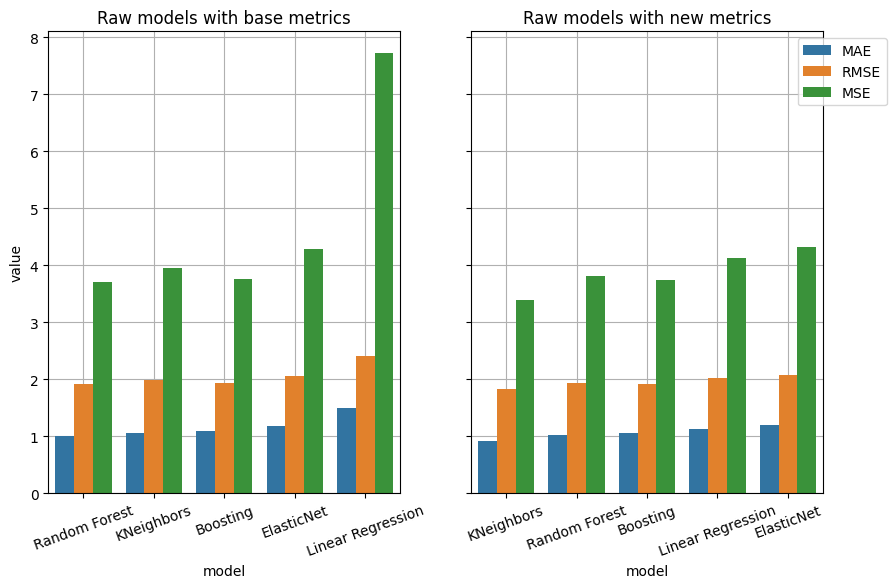

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 6))
show_metrics_plot("../data/logs/raw_model_metrics_on_row_data.csv", "Raw models with base metrics", axes[0])
show_metrics_plot("../data/logs/raw_model_metrics_new_features.csv", "Raw models with new metrics", axes[1])

Как можно заметить кодирование категориальных признаков дает весомый вклад, ну и лучшая модель из всех пока KNeighborsRegressor

# Linear models

## ElasticNet

In [12]:
def static_train_test_split(val_model: ModelValidation, train_folds: int = 2):
    """
    Split time data on train and test with train_folds folds for train and always 1 fold for test
    """

    splitter = val_model.split_data(n_splits=train_folds+1, window_type="expanding")
    last_split = None
    for split in splitter:
        last_split = split
    return last_split

In [ ]:
# Prepare data for ElasticNet model
# encode categorial features
data_new = encode_dataset(
    data,
    {
        'month': cyclical_encoding,
        'item_category_id': target_encoding,
        'item_id': target_encoding,
        'shop_id': one_hot_encoding
    }
)
# drop useless features
data_new = data_new.drop(columns=["date_block_num"])

data_new.head()

,item_cnt_month,month_sin,month_cos,item_category_id_TE,item_category_id_TE_NAN,item_id_TE,item_id_TE_NAN,shop_id_1,shop_id_2,shop_id_3,...,shop_id_47,shop_id_48,shop_id_49,shop_id_50,shop_id_51,shop_id_52,shop_id_53,shop_id_54,shop_id_55,shop_id_56
0,1.0,0.5,0.866025,0.0,1,0.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,0.5,0.866025,0.0,1,0.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0.5,0.866025,0.0,1,0.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0.5,0.866025,0.0,1,0.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2.0,0.5,0.866025,0.0,1,0.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# random search for first combination of encoding
val_model = ModelValidation(data_new, "item_cnt_month")
best_score, best_params, logs = random_search(
    ElasticNet,
    lambda: {
        "alpha": 10 ** np.random.uniform(-4, 1),
        "l1_ratio": np.random.uniform(0.1, 1.0),
        "max_iter": np.random.randint(500, 1500)
    },
    val_model,
    iter_count=20
)

print_results(best_score, best_params, logs)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [04:30<00:00, 13.55s/it]

1) RMSE [ 1.87] params: {'alpha': 0.0001591929343109182, 'l1_ratio': 0.3785556035718005, 'max_iter': 1168}
2) RMSE [ 1.855] params: {'alpha': 0.03564263208388604, 'l1_ratio': 0.9665434561328761, 'max_iter': 968}
3) RMSE [ 1.872] params: {'alpha': 0.00011989244696297674, 'l1_ratio': 0.6723321293119021, 'max_iter': 818}
4) RMSE [ 1.87] params: {'alpha': 0.072657160531194, 'l1_ratio': 0.5728691488926252, 'max_iter': 731}
5) RMSE [ 2.038] params: {'alpha': 1.0350517896650506, 'l1_ratio': 0.988659321707517, 'max_iter': 690}
6) RMSE [ 2.024] params: {'alpha': 1.102893365164238, 'l1_ratio': 0.8314308728104408, 'max_iter': 928}
7) RMSE [ 1.853] params: {'alpha': 0.0011025781522522714, 'l1_ratio': 0.34285075297319545, 'max_iter': 946}
8) RMSE [ 2.02] params: {'alpha': 4.353651433333637, 'l1_ratio': 0.10521028788743166, 'max_iter': 777}
9) RMSE [ 1.867] params: {'alpha': 0.00032519019364171393, 'l1_ratio': 0.5333766485184379, 'max_iter': 1162}
10) RMSE [ 1.834] params: {'alpha': 0.00437674761539

In [ ]:
# Trying enother combination of encoding
# let's make shop_id with TE and category_id with OHE

data_new = encode_dataset(
    data,
    {
        'month': cyclical_encoding,
        'item_category_id': one_hot_encoding,
        'item_id': target_encoding,
        'shop_id': target_encoding
    }
)
# drop useless features
data_new = data_new.drop(columns=["date_block_num"])

data_new.head()

,item_cnt_month,month_sin,month_cos,item_category_id_1,item_category_id_2,item_category_id_3,item_category_id_4,item_category_id_5,item_category_id_6,item_category_id_7,...,item_category_id_78,item_category_id_79,item_category_id_80,item_category_id_81,item_category_id_82,item_category_id_83,item_id_TE,item_id_TE_NAN,shop_id_TE,shop_id_TE_NAN
0,1.0,0.5,0.866025,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,1,0.0,1
1,1.0,0.5,0.866025,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,1,0.0,1
2,1.0,0.5,0.866025,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,1,0.0,1
3,1.0,0.5,0.866025,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,1,0.0,1
4,2.0,0.5,0.866025,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,1,0.0,1


In [ ]:
# random search for second combination of encoding
val_model = ModelValidation(data_new, "item_cnt_month")
best_score, best_params, logs = random_search(
    ElasticNet,
    lambda: {
        "alpha": 10 ** np.random.uniform(-4, 1),
        "l1_ratio": np.random.uniform(0.1, 1.0),
        "max_iter": np.random.randint(500, 1500)
    },
    val_model,
    iter_count=20
)

print_results(best_score, best_params, logs)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [03:59<00:00, 11.99s/it]

1) RMSE [ 1.9] params: {'alpha': 0.0013388607506350893, 'l1_ratio': 0.36446109000003535, 'max_iter': 726}
2) RMSE [ 1.874] params: {'alpha': 0.0893523124478009, 'l1_ratio': 0.3535628255677151, 'max_iter': 997}
3) RMSE [ 2.079] params: {'alpha': 9.982454480684757, 'l1_ratio': 0.3119685070878266, 'max_iter': 1187}
4) RMSE [ 1.906] params: {'alpha': 0.001714881258764584, 'l1_ratio': 0.8491590531269352, 'max_iter': 969}
5) RMSE [ 1.88] params: {'alpha': 0.002347451767910823, 'l1_ratio': 0.10224574325148698, 'max_iter': 1401}
6) RMSE [ 1.855] params: {'alpha': 0.011539367281149801, 'l1_ratio': 0.882039883886165, 'max_iter': 1222}
7) RMSE [ 1.922] params: {'alpha': 0.0004683923796707052, 'l1_ratio': 0.43742452381512653, 'max_iter': 823}
8) RMSE [ 1.934] params: {'alpha': 0.00023833197173463847, 'l1_ratio': 0.8988850780544828, 'max_iter': 929}
9) RMSE [ 1.854] params: {'alpha': 0.009459496606491605, 'l1_ratio': 0.3460879625529992, 'max_iter': 1432}
10) RMSE [ 1.868] params: {'alpha': 0.007650

### Вывод:

Модели с лучшим скором получаются при комбинации кодирования категориальных фич как в первом подходе

shop_id -- OHE

item_category_id, item_id -- TE

### Shap

In [13]:
def show_shap(model, val_model):
    # split our data 32:1 train:test
    (X_train, X_test, y_train, y_test) = static_train_test_split(val_model, train_folds=32)
    explainer = shap.Explainer(model.predict, X_train)
    # take only 1000 samples because of long time for computing
    shap_values = explainer(X_test.iloc[14500:14600])
    shap.plots.bar(shap_values)

In [ ]:
# make final dataset for ElasticNet
data_elastic = encode_dataset(
    data,
    {
        'month': cyclical_encoding,
        'item_category_id': target_encoding,
        'item_id': target_encoding,
        'shop_id': one_hot_encoding
    }
)
data_elastic = data_elastic.drop(columns=['date_block_num'])

# Train the best model with found parameters
val_model = ModelValidation(data_elastic, "item_cnt_month")
splitter = val_model.split_data(n_splits=33, window_type='sliding', train_size=2)
model = fit_validate(ElasticNet(alpha=0.004, l1_ratio=0.3, max_iter=1000), splitter, [RMSE, MAE, MSE], val_model, return_last=True, show_logs=False)

Average RMSE during training: 1.8344365125138675
Average MAE during training: 1.0207353803452168
Average MSE during training: 3.401059948072143


PermutationExplainer explainer: 1001it [00:40, 18.50it/s]                                                                                                         


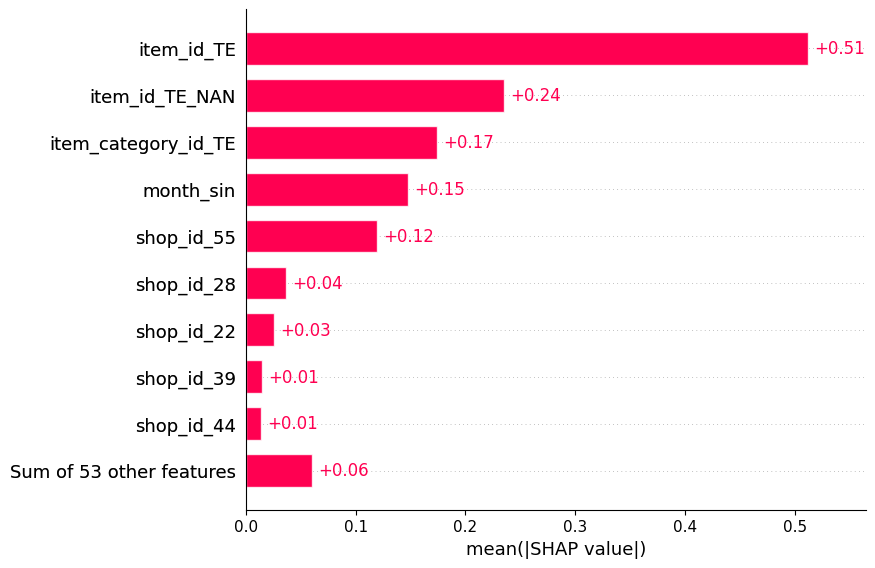

In [ ]:
show_shap(model, val_model)

Как можно заметить month_cos и item_category_id_TE_NAN не привносят в предсказание большого вклада, в дальнейшем их можно убрать. Остальные признаки вносят весомый вклад (кроме OHE shop_id но удалять часть из них будто неправильно)

## LinearRegression

In [ ]:
# test LinearRegression on data for ElasticNet

val_model = ModelValidation(data_elastic, "item_cnt_month")
splitter = val_model.split_data(n_splits=33, window_type='sliding', train_size=2)
model = fit_validate(LinearRegression(), splitter, [RMSE, MAE, MSE], val_model, return_last=True, show_logs=False)

Average RMSE during training: 1.8763516476858513
Average MAE during training: 1.090429862494952
Average MSE during training: 3.5668166973831044


### Shap

PermutationExplainer explainer: 1001it [00:40, 18.81it/s]                                                                                                         


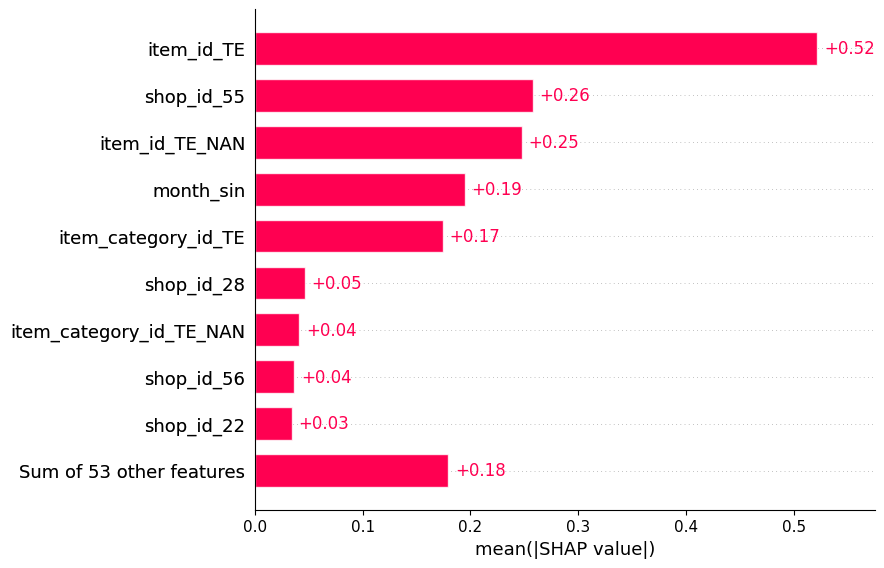

In [ ]:
show_shap(model, val_model)

## Вывод

ElasticNet и LinearRegression ожидаемо показали похожие результаты. Они по разному используют признаки, LinearRegression больше полагается на shop_id и обе эти модели не используют month_cos

# KNeighbors

In [ ]:
model = KNeighborsRegressor(metric='hamming')

In [ ]:
data_knn = data.drop(columns='date_block_num')

# simulate grid search
def get_params():
    for n_neighbors in range(2, 21, 3): # 7
        for weight in ["uniform", "distance"]: # 2
            for p in [1, 2, 3]: # 3
                yield {
                        "n_neighbors": n_neighbors,
                        "weights": weight,
                        "metric": 'minkowski',
                        "p": p # Manhattan / Euclidean / minkovski with p =3
                    }

param_generator = get_params()

val_model = ModelValidation(data_knn, "item_cnt_month")
best_score, best_params, logs = random_search(
    KNeighborsRegressor,
    lambda: next(param_generator),
    val_model,
    iter_count=7*2*3
)

print_results(best_score, best_params, logs)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [10:30<00:00, 15.01s/it]

1) RMSE [ 2.063] params: {'n_neighbors': 2, 'weights': 'uniform', 'metric': 'minkowski', 'p': 1}
2) RMSE [ 2.07] params: {'n_neighbors': 2, 'weights': 'uniform', 'metric': 'minkowski', 'p': 2}
3) RMSE [ 2.072] params: {'n_neighbors': 2, 'weights': 'uniform', 'metric': 'minkowski', 'p': 3}
4) RMSE [ 2.042] params: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'minkowski', 'p': 1}
5) RMSE [ 2.053] params: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'minkowski', 'p': 2}
6) RMSE [ 2.058] params: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'minkowski', 'p': 3}
7) RMSE [ 1.945] params: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'minkowski', 'p': 1}
8) RMSE [ 1.961] params: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'minkowski', 'p': 2}
9) RMSE [ 1.964] params: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'minkowski', 'p': 3}
10) RMSE [ 1.911] params: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'minkowski', 'p': 1}
11) RMSE [ 1.934] params: 

Как видно, лучшие показатели KNN у нас при максимальном n_neighbors, манхетеннской метрике расстояния и весах равных инверсированной дистанции

In [ ]:
# train the best KNN model
data_knn = data.copy()
data_knn = data_knn.drop(columns='date_block_num')

# Train the best model with found parameters
val_model = ModelValidation(data_knn, "item_cnt_month")
splitter = val_model.split_data(n_splits=33, window_type='sliding', train_size=2)
model = fit_validate(
    KNeighborsRegressor(n_neighbors=20, weights='distance', metric='minkowski', p=1),
    splitter,
    [RMSE, MAE, MSE],
    val_model,
    return_last=True,
    show_logs=False
)

Average RMSE during training: 1.8550060984115353
Average MAE during training: 1.026903273380139
Average MSE during training: 3.4679075066899294


ExactExplainer explainer: 1001it [00:22, 31.77it/s]                                                                                                               


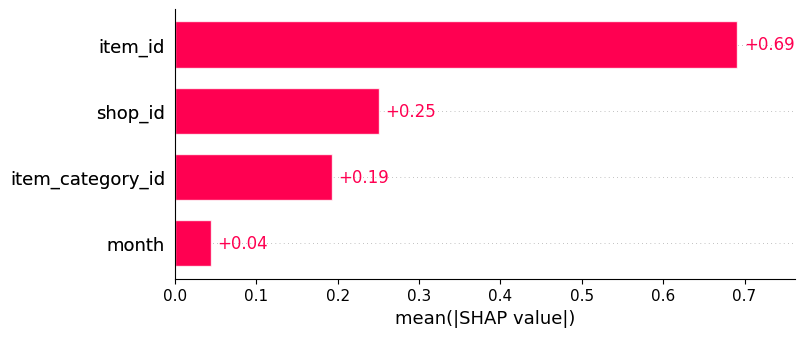

In [ ]:
show_shap(model, val_model)

In [ ]:
# train second KNN model
# use some encodings
data_knn = encode_dataset(
    data,
    {
        'item_category_id': target_encoding,
        'item_id': target_encoding,
        'shop_id': target_encoding
    }
)
data_knn = data_knn.drop(columns=['date_block_num'])

# scale numeric features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ['item_id_TE', 'shop_id_TE', 'item_category_id_TE', 'month']
data_knn[features_to_scale] = scaler.fit_transform(data_knn[features_to_scale])


# Train the best model with found parameters
val_model = ModelValidation(data_knn, "item_cnt_month")
splitter = val_model.split_data(n_splits=33, window_type='sliding', train_size=2)
model = fit_validate(
    KNeighborsRegressor(n_neighbors=20, weights='distance', metric='minkowski', p=1),
    splitter,
    [RMSE, MAE, MSE],
    val_model,
    return_last=True,
    show_logs=False
)

Average RMSE during training: 1.8256300841379685
Average MAE during training: 0.9478039153485267
Average MSE during training: 3.3704307000877316


ExactExplainer explainer: 101it [00:22,  2.54it/s]                                                                                                                


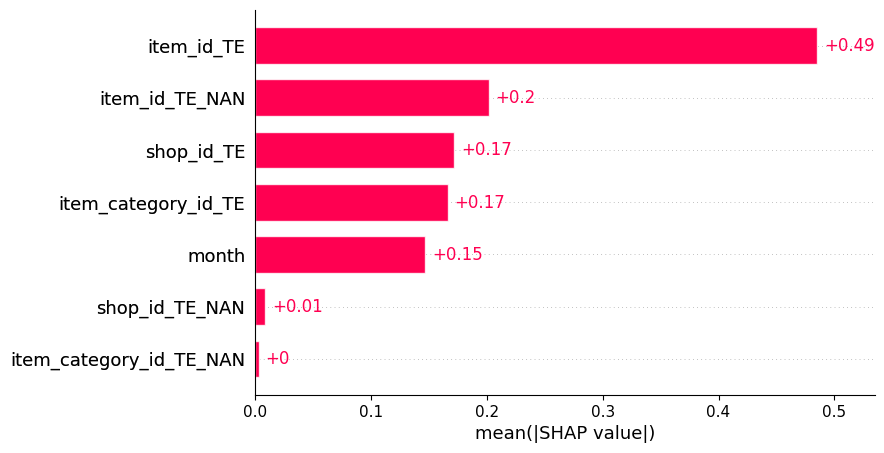

In [ ]:
show_shap(model, val_model)

## Вывод
KNN ожидаемо немного лучше показал себя с кодированием категориальных переменных и масштабированием

# Trees

### Catboost


In [ ]:
from catboost import CatBoostRegressor

In [17]:
data_tree = data.copy()
data_tree = data_tree.drop(columns='date_block_num')
data_tree['month'] = data_tree['month'].astype(int)
data_tree['item_category_id'] = data_tree['item_category_id'].astype(int)
data_tree.head()

,shop_id,item_id,item_cnt_month,item_category_id,month
0,0,27,1.0,19,1
1,0,33,1.0,37,1
2,0,317,1.0,45,1
3,0,438,1.0,45,1
4,0,471,2.0,49,1


Catboost покаал себя не очень, пытался обучить его на сыром датасете пометив все фичи как категориальные, получилось не очень

In [ ]:
# test catboost model

val_model = ModelValidation(data_tree, 'item_cnt_month')
best_score, best_params, logs = random_search(
    CatBoostRegressor,
    lambda: {
        'iterations': np.random.randint(10, 20),  # Количество деревьев
        'depth': np.random.randint(3, 12),  # Глубина дерева
        'learning_rate': np.random.uniform(0.01, 0.2),  # Скорость обучения
        'l2_leaf_reg': np.random.uniform(1, 10),  # Регуляризация на листьях
        # 'cat_features': [0, 1, 2, 3]
    },
    val_model,
    iter_count=5
)
print_results(best_score, best_params, logs)

  0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 1.9056590	total: 12.9ms	remaining: 129ms
1:	learn: 1.8858929	total: 38ms	remaining: 171ms
2:	learn: 1.8686371	total: 46.7ms	remaining: 125ms
3:	learn: 1.8540018	total: 86.2ms	remaining: 151ms
4:	learn: 1.8431603	total: 103ms	remaining: 124ms
5:	learn: 1.8331963	total: 148ms	remaining: 123ms
6:	learn: 1.8240365	total: 157ms	remaining: 89.6ms
7:	learn: 1.8146601	total: 191ms	remaining: 71.4ms
8:	learn: 1.8075530	total: 219ms	remaining: 48.6ms
9:	learn: 1.8011013	total: 242ms	remaining: 24.2ms
10:	learn: 1.7953997	total: 261ms	remaining: 0us
0:	learn: 2.1124514	total: 32.3ms	remaining: 323ms
1:	learn: 2.0939423	total: 66.7ms	remaining: 300ms
2:	learn: 2.0765667	total: 115ms	remaining: 305ms
3:	learn: 2.0633567	total: 170ms	remaining: 297ms
4:	learn: 2.0518232	total: 225ms	remaining: 270ms
5:	learn: 2.0425058	total: 291ms	remaining: 242ms
6:	learn: 2.0355465	total: 346ms	remaining: 198ms
7:	learn: 2.0293346	total: 407ms	remaining: 153ms
8:	learn: 2.0243146	total: 453ms	remaining:

 20%|██        | 1/5 [00:07<00:28,  7.06s/it]

0:	learn: 2.2638686	total: 10ms	remaining: 100ms
1:	learn: 2.2478135	total: 19.8ms	remaining: 89.1ms
2:	learn: 2.2349171	total: 29.1ms	remaining: 77.6ms
3:	learn: 2.2255759	total: 34.6ms	remaining: 60.5ms
4:	learn: 2.2172668	total: 44.9ms	remaining: 53.8ms
5:	learn: 2.2085124	total: 54.3ms	remaining: 45.2ms
6:	learn: 2.1981914	total: 63.5ms	remaining: 36.3ms
7:	learn: 2.1914448	total: 72.8ms	remaining: 27.3ms
8:	learn: 2.1836709	total: 82ms	remaining: 18.2ms
9:	learn: 2.1797436	total: 91.1ms	remaining: 9.11ms
10:	learn: 2.1764549	total: 100ms	remaining: 0us
0:	learn: 1.9118359	total: 2.13ms	remaining: 23.5ms
1:	learn: 1.8978979	total: 4.18ms	remaining: 20.9ms
2:	learn: 1.8877147	total: 6.01ms	remaining: 18ms
3:	learn: 1.8781565	total: 7.74ms	remaining: 15.5ms
4:	learn: 1.8700113	total: 9.63ms	remaining: 13.5ms
5:	learn: 1.8635786	total: 11.5ms	remaining: 11.5ms
6:	learn: 1.8573410	total: 13.3ms	remaining: 9.52ms
7:	learn: 1.8525282	total: 15.1ms	remaining: 7.56ms
8:	learn: 1.8496917	to

 40%|████      | 2/5 [00:09<00:13,  4.58s/it]

...

0:	learn: 1.9190703	total: 20.4ms	remaining: 367ms
1:	learn: 1.9103060	total: 46.8ms	remaining: 398ms
2:	learn: 1.9016950	total: 62.5ms	remaining: 333ms
3:	learn: 1.8933687	total: 89.3ms	remaining: 335ms
4:	learn: 1.8858447	total: 118ms	remaining: 330ms
5:	learn: 1.8785733	total: 143ms	remaining: 311ms
6:	learn: 1.8719846	total: 170ms	remaining: 292ms
7:	learn: 1.8677747	total: 179ms	remaining: 246ms
8:	learn: 1.8619828	total: 207ms	remaining: 230ms
9:	learn: 1.8564637	total: 226ms	remaining: 204ms
10:	learn: 1.8510055	total: 249ms	remaining: 181ms
11:	learn: 1.8464290	total: 277ms	remaining: 162ms
12:	learn: 1.8417887	total: 304ms	remaining: 140ms
13:	learn: 1.8378364	total: 330ms	remaining: 118ms
14:	learn: 1.8331470	total: 356ms	remaining: 94.9ms
15:	learn: 1.8296092	total: 361ms	remaining: 67.7ms
16:	learn: 1.8261095	total: 377ms	remaining: 44.4ms
17:	learn: 1.8225188	total: 400ms	remaining: 22.2ms
18:	learn: 1.8191994	total: 426ms	remaining: 0us
0:	learn: 2.1264707	total: 21ms	rem

 80%|████████  | 4/5 [00:25<00:07,  7.16s/it]

10:	learn: 2.2187929	total: 135ms	remaining: 98.1ms
11:	learn: 2.2140630	total: 149ms	remaining: 87ms
12:	learn: 2.2098154	total: 163ms	remaining: 75.2ms
13:	learn: 2.2062174	total: 177ms	remaining: 63.2ms
14:	learn: 2.2029100	total: 191ms	remaining: 50.8ms
15:	learn: 2.1998570	total: 204ms	remaining: 38.3ms
16:	learn: 2.1961627	total: 218ms	remaining: 25.7ms
17:	learn: 2.1923332	total: 232ms	remaining: 12.9ms
18:	learn: 2.1890093	total: 245ms	remaining: 0us
0:	learn: 1.8943310	total: 3.71ms	remaining: 55.7ms
1:	learn: 1.8674428	total: 7.03ms	remaining: 49.2ms
2:	learn: 1.8485075	total: 10.4ms	remaining: 45.1ms
3:	learn: 1.8358707	total: 13.7ms	remaining: 41.1ms
4:	learn: 1.8251269	total: 16.9ms	remaining: 37.2ms
5:	learn: 1.8157673	total: 20.1ms	remaining: 33.6ms
6:	learn: 1.8058604	total: 23.3ms	remaining: 29.9ms
7:	learn: 1.8005552	total: 26.6ms	remaining: 26.6ms
8:	learn: 1.7941081	total: 29.8ms	remaining: 23.2ms
9:	learn: 1.7913075	total: 32.9ms	remaining: 19.7ms
10:	learn: 1.7874

100%|██████████| 5/5 [00:32<00:00,  6.41s/it]

0:	learn: 2.2560348	total: 9.5ms	remaining: 143ms
1:	learn: 2.2373118	total: 15.4ms	remaining: 108ms
2:	learn: 2.2227713	total: 20.2ms	remaining: 87.7ms
3:	learn: 2.2108335	total: 26.5ms	remaining: 79.4ms
4:	learn: 2.2041594	total: 32.4ms	remaining: 71.2ms
5:	learn: 2.1963707	total: 38.3ms	remaining: 63.8ms
6:	learn: 2.1855926	total: 44.2ms	remaining: 56.8ms
7:	learn: 2.1808664	total: 50.2ms	remaining: 50.2ms
8:	learn: 2.1748626	total: 56.1ms	remaining: 43.6ms
9:	learn: 2.1682166	total: 62ms	remaining: 37.2ms
10:	learn: 2.1632720	total: 68ms	remaining: 30.9ms
11:	learn: 2.1608736	total: 73.7ms	remaining: 24.6ms
12:	learn: 2.1554501	total: 79.4ms	remaining: 18.3ms
13:	learn: 2.1535761	total: 85.1ms	remaining: 12.2ms
14:	learn: 2.1501155	total: 91ms	remaining: 6.07ms
15:	learn: 2.1472826	total: 96.7ms	remaining: 0us
1) RMSE [ 2.039] params: {'iterations': 11, 'depth': 9, 'learning_rate': 0.1141230698123216, 'l2_leaf_reg': 7.116624000215705}
2) RMSE [ 2.053] params: {'iterations': 12, 'de

### GradientBosting

Пробуем закодировать категории для бустинга и случайного леса

In [20]:

data_tree_new = encode_dataset(
    data,
    {
        'month': cyclical_encoding,
        'item_category_id': target_encoding,
        'item_id': target_encoding,
        'shop_id': target_encoding
    }
)
data_tree_new = data_tree_new.drop(columns=['date_block_num'])

Случайный поиск гиперпараметров

In [ ]:
val_model = ModelValidation(data_tree_new, 'item_cnt_month')
best_score, best_params, logs = random_search(
    GradientBoostingRegressor,
    lambda: {
        "n_estimators": np.random.randint(50, 150),
        "learning_rate": np.random.uniform(0.01, 0.2),
        "max_depth": np.random.randint(2, 8),
        "min_samples_split": np.random.randint(5, 50),
    },
    val_model,
    iter_count=20
)
print_results(best_score, best_params, logs)

100%|██████████| 20/20 [28:13<00:00, 84.69s/it]

1) RMSE [ 1.822] params: {'n_estimators': 101, 'learning_rate': 0.05407617452979395, 'max_depth': 5, 'min_samples_split': 43}
2) RMSE [ 1.826] params: {'n_estimators': 80, 'learning_rate': 0.13605136388220113, 'max_depth': 5, 'min_samples_split': 26}
3) RMSE [ 1.825] params: {'n_estimators': 87, 'learning_rate': 0.13606673830364593, 'max_depth': 5, 'min_samples_split': 41}
4) RMSE [ 1.831] params: {'n_estimators': 79, 'learning_rate': 0.10277361182191247, 'max_depth': 3, 'min_samples_split': 29}
5) RMSE [ 1.835] params: {'n_estimators': 129, 'learning_rate': 0.15658302152890038, 'max_depth': 2, 'min_samples_split': 30}
6) RMSE [ 1.826] params: {'n_estimators': 137, 'learning_rate': 0.16311169124818048, 'max_depth': 3, 'min_samples_split': 38}
7) RMSE [ 1.822] params: {'n_estimators': 113, 'learning_rate': 0.13493898326374956, 'max_depth': 4, 'min_samples_split': 37}
8) RMSE [ 1.828] params: {'n_estimators': 143, 'learning_rate': 0.09486586087314752, 'max_depth': 3, 'min_samples_split':

### RandomForest

Случайный поиск гиперпараметров

In [ ]:
val_model = ModelValidation(data_tree_new, 'item_cnt_month')
best_score, best_params, logs = random_search(
    RandomForestRegressor,
    lambda: {
        "n_estimators": np.random.randint(50, 150),
        "max_depth": np.random.randint(5, 30),
        "max_features": np.random.choice(["sqrt", "log2"]),
        "min_samples_split": np.random.randint(2, 50),
    },
    val_model,
    iter_count=20
)
print_results(best_score, best_params, logs)

100%|██████████| 20/20 [26:49<00:00, 80.47s/it]

1) RMSE [ 1.825] params: {'n_estimators': 89, 'max_depth': 12, 'max_features': np.str_('log2'), 'min_samples_split': 28}
2) RMSE [ 1.835] params: {'n_estimators': 99, 'max_depth': 15, 'max_features': np.str_('sqrt'), 'min_samples_split': 20}
3) RMSE [ 1.825] params: {'n_estimators': 96, 'max_depth': 29, 'max_features': np.str_('log2'), 'min_samples_split': 45}
4) RMSE [ 1.828] params: {'n_estimators': 109, 'max_depth': 16, 'max_features': np.str_('sqrt'), 'min_samples_split': 47}
5) RMSE [ 1.84] params: {'n_estimators': 147, 'max_depth': 22, 'max_features': np.str_('sqrt'), 'min_samples_split': 16}
6) RMSE [ 1.831] params: {'n_estimators': 127, 'max_depth': 22, 'max_features': np.str_('sqrt'), 'min_samples_split': 32}
7) RMSE [ 1.859] params: {'n_estimators': 126, 'max_depth': 16, 'max_features': np.str_('sqrt'), 'min_samples_split': 6}
8) RMSE [ 1.824] params: {'n_estimators': 124, 'max_depth': 23, 'max_features': np.str_('log2'), 'min_samples_split': 46}
9) RMSE [ 1.846] params: {'n_

### Shap

Average RMSE during training: 1.8146250907326156
Average MAE during training: 0.9579136595791249
Average MSE during training: 3.3362685051189827


ExactExplainer explainer: 101it [00:10,  1.73it/s]                                                                                                                


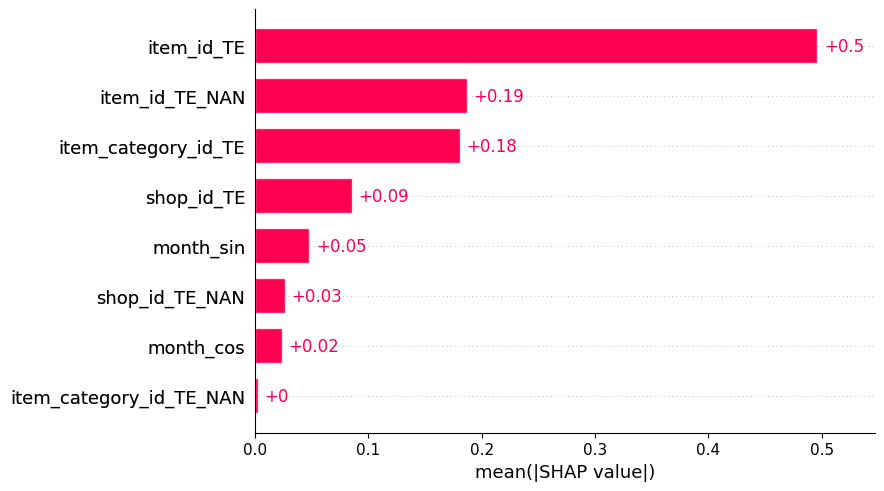

In [21]:
val_model = ModelValidation(data_tree_new, "item_cnt_month")
splitter = val_model.split_data(n_splits=33, window_type='sliding', train_size=2)
model = fit_validate(
    GradientBoostingRegressor(
        n_estimators=120,
        learning_rate=0.14,
        max_depth=4,
        min_samples_split=37,
    ),
    splitter,
    [RMSE, MAE, MSE],
    val_model,
    return_last=True,
    show_logs=False
)
show_shap(model, val_model)

Оказалось, что на Google Colab модели обучались только на половине данных поэтому присутствует различие по метрикам в Random Search и когда я обучаю лучшую модель.

Average RMSE during training: 1.791142199593673
Average MAE during training: 0.9546768855982481
Average MSE during training: 3.2489420715966966


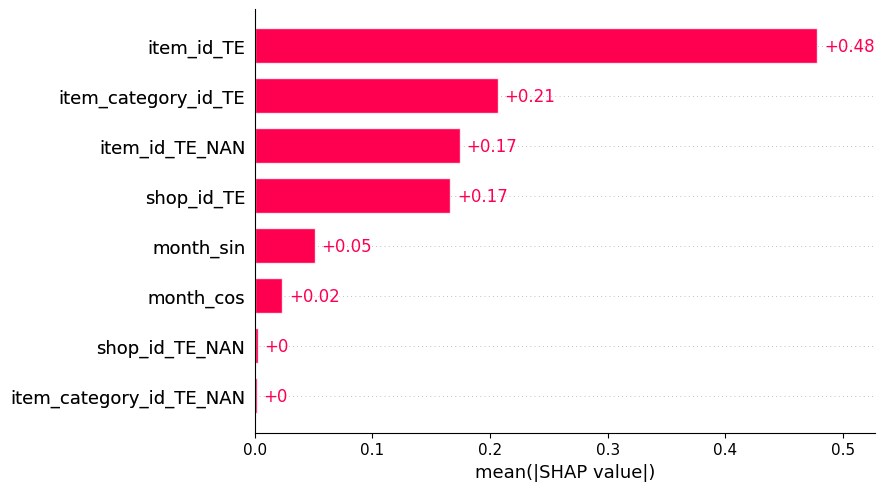

In [22]:
val_model = ModelValidation(data_tree_new, "item_cnt_month")
splitter = val_model.split_data(n_splits=33, window_type='sliding', train_size=2)
model = fit_validate(
    RandomForestRegressor(
        n_estimators=120,
        max_depth=10,
        max_features="log2",
        min_samples_split=40,
    ),
    splitter,
    [RMSE, MAE, MSE],
    val_model,
    return_last=True,
    show_logs=False
)
show_shap(model, val_model)

Тут тоже отличие из-за того, что обучение в коллаб шло только на половине данных. Видно, что модель практически не использует параметры с флагами пропусков.

## Вывод
Случайный лес показал метрику лучше, чем бустинг надо брать его

# Выводы глобальные

Было замечено, что ошибка реско растет, если убрать удаление выбросов в слое ETL

сводная таблица


| Model              | RMSE  |
|--------------------|-------|
| ElasticNet         | 1.83  |
| LinearRegression   | 1.87  |
| KNN                | 1.82  |
| CatBoost           | 2.02  |
| GradientBoosting   | 1.81  |
| RandomForest       | 1.79  |

Ну и в заключение, смотря на метрикик я выбираю RandomForest как основное